         Palavra  Frequência
1695      dívida          51
1698     bilhões          33
1503    educação          33
1252     pública          32
1591     milhões          30
1873        anos          30
354         mais          28
523        reais          24
1410      gastos          23
246    população          23
9        sistema          23
1582       entre          22
951   transporte          21
950         2010          21
725       brasil          20


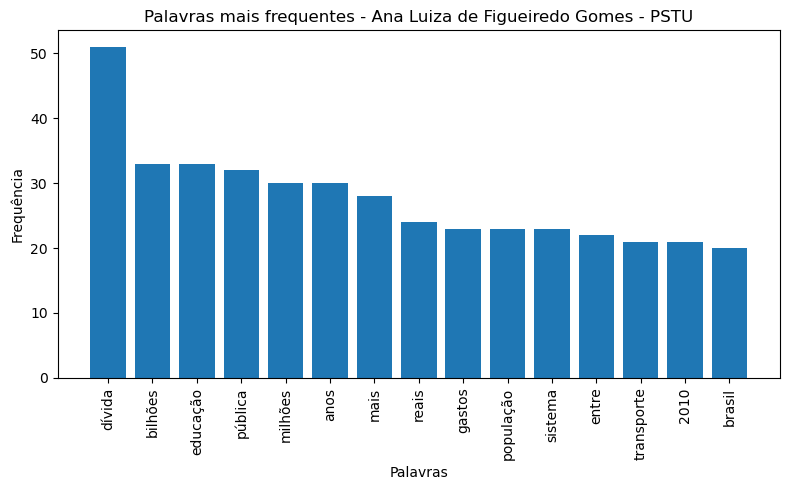

        Palavra  Frequência
525    política          15
454    educação          12
112  prefeitura          10
737         ser          10
343        mais          10
736      social           9
823  transporte           8
749         tem           8
816       velha           8
193      contra           8
670       serra           7
359  defendemos           6
788   políticas           6
658        povo           6
136   município           5


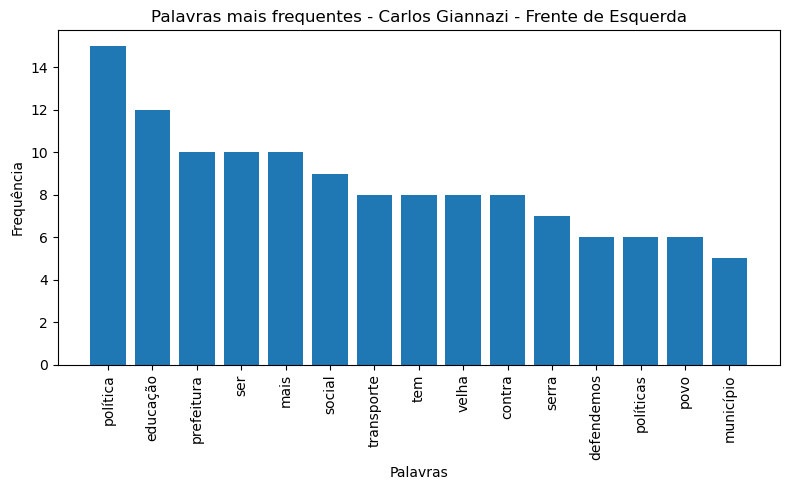

          Palavra  Frequência
440          mais          20
852       capital          17
210         saúde          15
139    prefeitura          14
300     população          11
121     qualidade          11
940           ser          10
219          será          10
965        centro          10
474   atendimento           9
831      trânsito           9
1035         cada           9
669            ou           9
538          hoje           8
20           suas           8


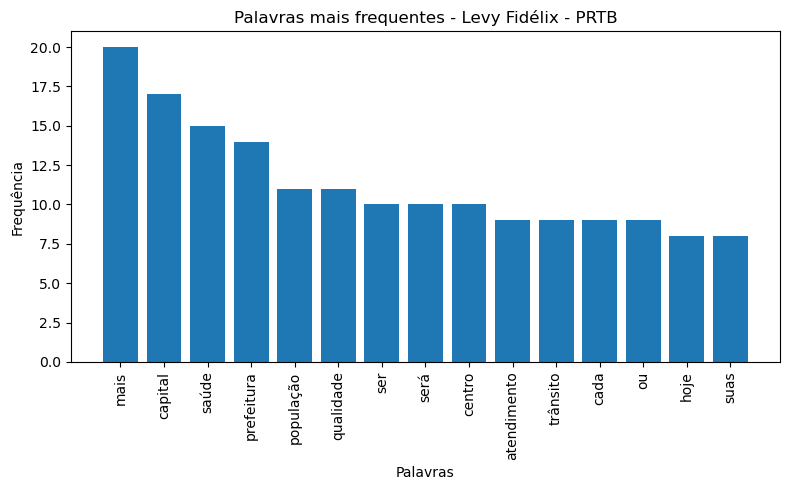

           Palavra  Frequência
465        ampliar          20
202        através          19
637          criar          18
454      municipal          17
170          saúde          15
361              1          14
251      população          13
542  administração          12
862           rede          12
215            fim          12
367              2          12
294        criação          12
853          áreas          11
802         centro          11
379      implantar          11


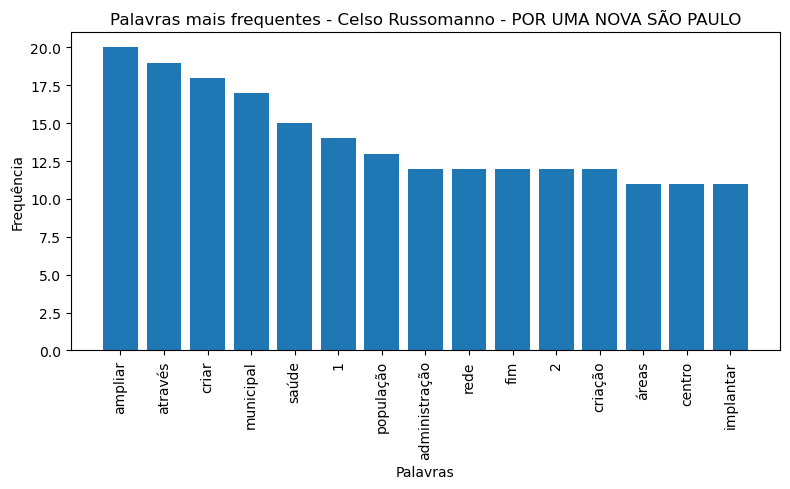

             Palavra  Frequência
269             mais           9
137            criar           4
134            saúde           4
10           sistema           4
89                ou           3
128         trabalho           3
297         comércio           3
58   desenvolvimento           3
274            lazer           3
307            fazer           3
160           outros           3
77          oferecer           3
45          educação           3
311          central           3
313            áreas           3


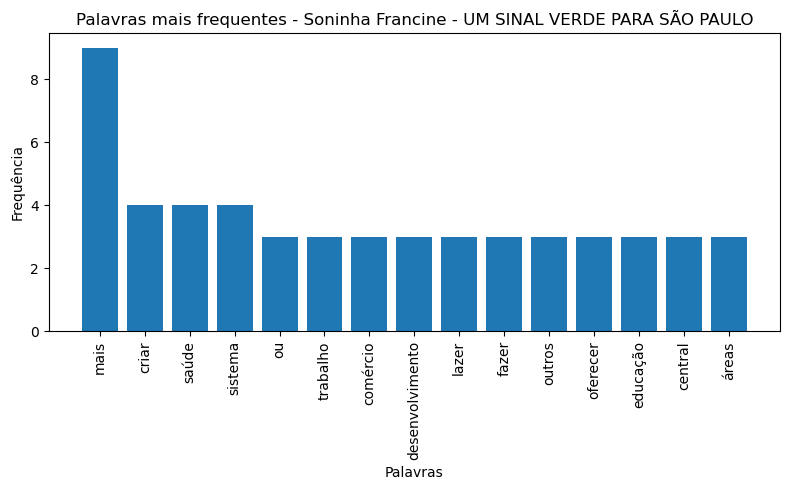

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


# Mapeamento e listagem de arquivos e nome do candidato para legenda do gráfico
arquivos = {
    "resultados/output_ana.txt": "Ana Luiza de Figueiredo Gomes - PSTU",
    "resultados/output_giannazi.txt": "Carlos Giannazi - Frente de Esquerda",
    "resultados/output_levy.txt": "Levy Fidélix - PRTB",
    "resultados/output_russomanno.txt": "Celso Russomanno - POR UMA NOVA SÃO PAULO",
    "resultados/output_soninha.txt": "Soninha Francine - UM SINAL VERDE PARA SÃO PAULO"
}

# Leitura dos arquivos e montagem dos gráficos
for arquivo, nome in arquivos.items():

    df = pd.read_csv(arquivo, sep="\s+", engine="python", header=None)
    df.columns = ["Palavra", "Frequência"]

    df = df.sort_values(by="Frequência", ascending=False)

    top = df.head(15)

    print(top)

    plt.figure(figsize=(8,5))
    plt.bar(top["Palavra"], top["Frequência"])

    plt.title(f"Palavras mais frequentes - {nome}")
    plt.xlabel("Palavras")
    plt.ylabel("Frequência")

    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

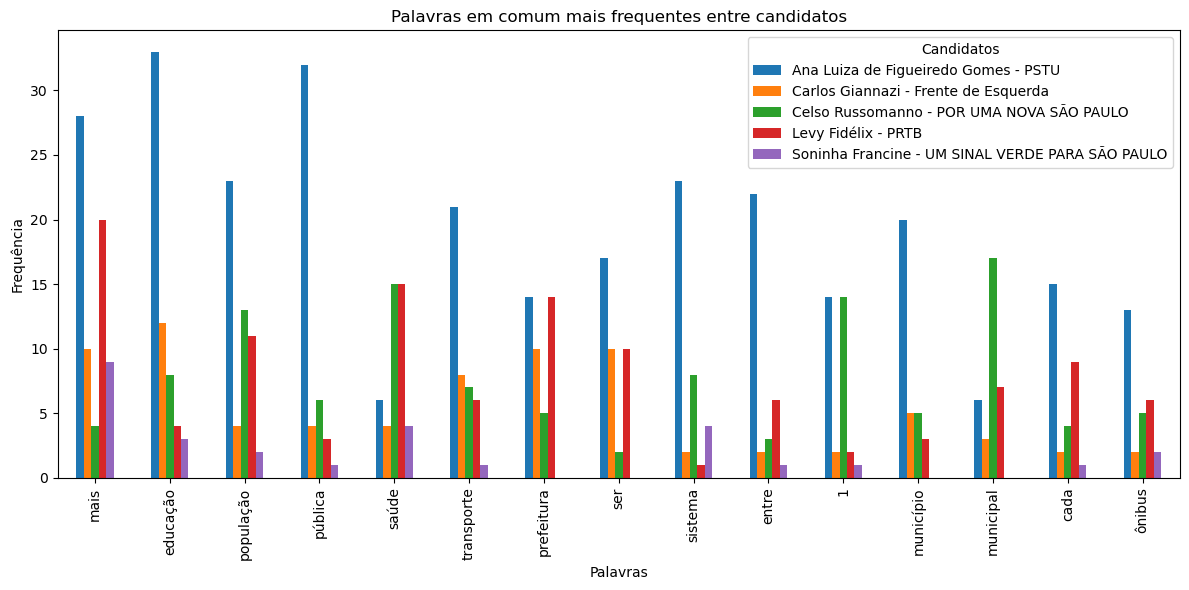

Candidato   Ana Luiza de Figueiredo Gomes - PSTU  \
Palavra                                            
mais                                        28.0   
educação                                    33.0   
população                                   23.0   
pública                                     32.0   
saúde                                        6.0   
transporte                                  21.0   
prefeitura                                  14.0   
ser                                         17.0   
sistema                                     23.0   
entre                                       22.0   
1                                           14.0   
município                                   20.0   
municipal                                    6.0   
cada                                        15.0   
ônibus                                      13.0   

Candidato   Carlos Giannazi - Frente de Esquerda  \
Palavra                                            
mais       

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Mapeamento e listagem de arquivos e nome do candidato para legenda do gráfico
arquivos = {
    "resultados/output_ana.txt": "Ana Luiza de Figueiredo Gomes - PSTU",
    "resultados/output_giannazi.txt": "Carlos Giannazi - Frente de Esquerda",
    "resultados/output_levy.txt": "Levy Fidélix - PRTB",
    "resultados/output_russomanno.txt": "Celso Russomanno - POR UMA NOVA SÃO PAULO",
    "resultados/output_soninha.txt": "Soninha Francine - UM SINAL VERDE PARA SÃO PAULO"
}

dfs = []

# Ler e armazenar dados
for arquivo, nome in arquivos.items():
    df = pd.read_csv(arquivo, sep="\s+", engine="python", header=None)
    df.columns = ["Palavra", "Frequência"]

    df["Candidato"] = nome
    dfs.append(df)

# Concatena informação de todos os arquivos
df_total = pd.concat(dfs, ignore_index=True)

# Pivot (tabela comparativa)
pivot = df_total.pivot_table(
    index="Palavra",
    columns="Candidato",
    values="Frequência",
    fill_value=0
)

# Filtra palavras que aparecem em pelo menos 4 candidatos
pivot["Qtd_Candidatos"] = (pivot > 0).sum(axis=1)
pivot_filtrado = pivot[pivot["Qtd_Candidatos"] >= 4]

# Filtra palavras que aparecem no minimo 5 vezes
frequencia_minima = 5
pivot_filtrado = pivot_filtrado[
    (pivot_filtrado.drop(columns="Qtd_Candidatos") >= frequencia_minima).any(axis=1)
]

# Soma total
pivot_filtrado["Total"] = pivot_filtrado.drop(columns="Qtd_Candidatos").sum(axis=1)

# Top 15
top15 = pivot_filtrado.sort_values(by="Total", ascending=False).head(15)

# Remover colunas auxiliares
top15_plot = top15.drop(columns=["Total", "Qtd_Candidatos"])

# Gráfico
ax = top15_plot.plot(kind="bar", figsize=(12,6))

plt.title("Palavras em comum mais frequentes entre candidatos")
plt.xlabel("Palavras")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.legend(title="Candidatos")

plt.tight_layout()
plt.show()

print(top15_plot)

Candidato
Ana Luiza Gomes     21.0
Carlos Giannazi      8.0
Celso Russomanno     7.0
Levy Fidélix         6.0
Soninha Francine     1.0
Name: transporte, dtype: float64


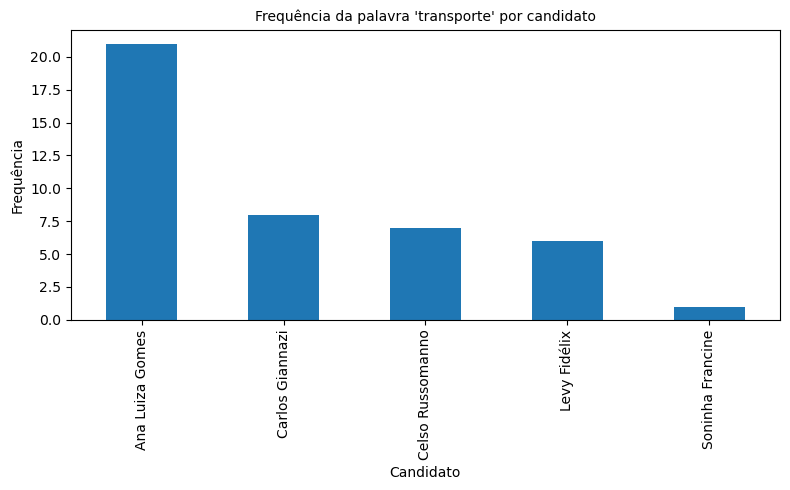

Candidato
Ana Luiza Gomes     33.0
Carlos Giannazi     12.0
Celso Russomanno     8.0
Levy Fidélix         4.0
Soninha Francine     3.0
Name: educação, dtype: float64


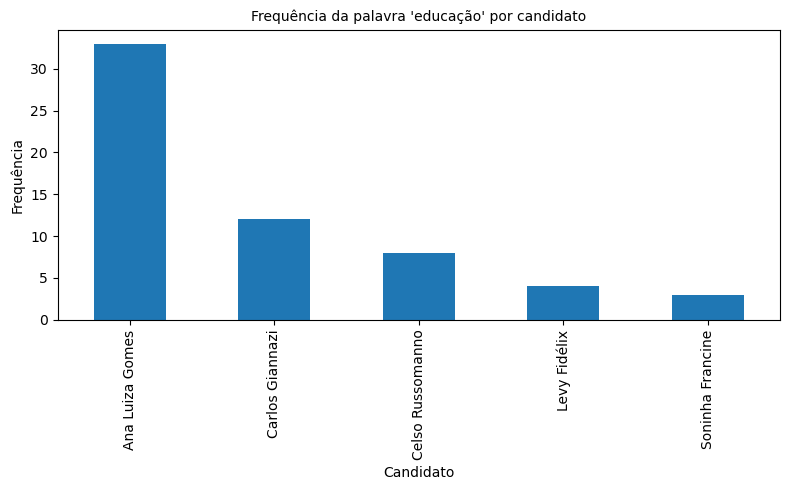

Candidato
Ana Luiza Gomes      6.0
Carlos Giannazi      4.0
Celso Russomanno    15.0
Levy Fidélix        15.0
Soninha Francine     4.0
Name: saúde, dtype: float64


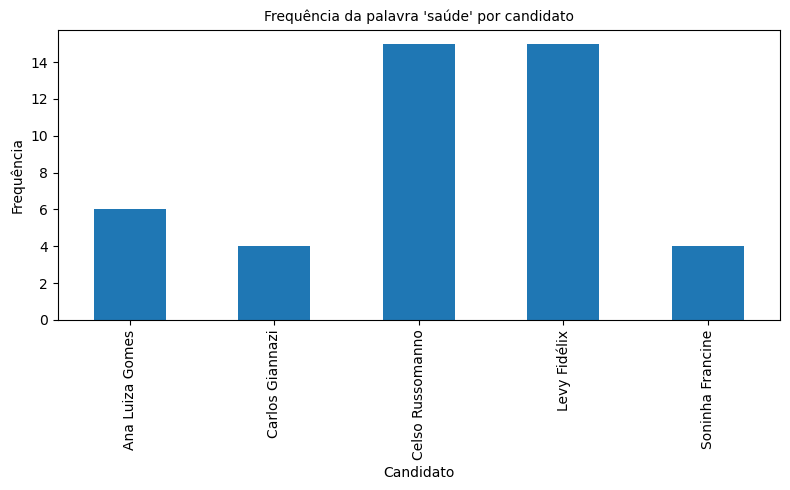

Candidato
Ana Luiza Gomes     13.0
Carlos Giannazi      2.0
Celso Russomanno     6.0
Levy Fidélix         3.0
Soninha Francine     2.0
Name: segurança, dtype: float64


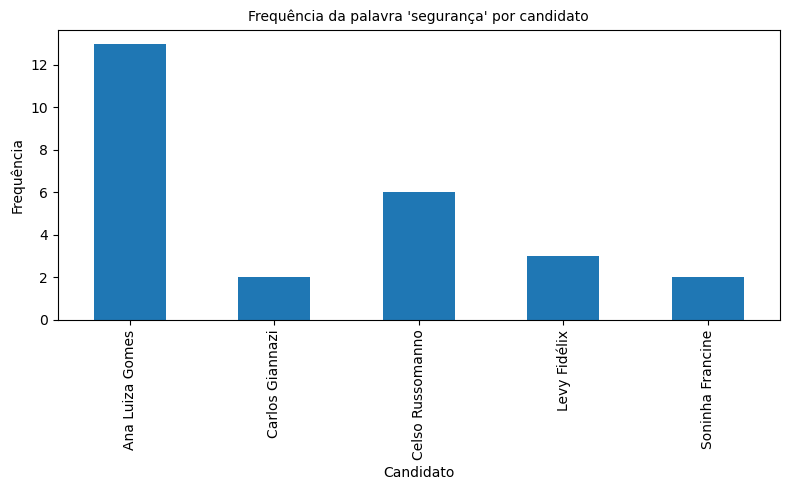

Candidato
Ana Luiza Gomes     1.0
Carlos Giannazi     2.0
Celso Russomanno    4.0
Levy Fidélix        0.0
Soninha Francine    1.0
Name: emprego, dtype: float64


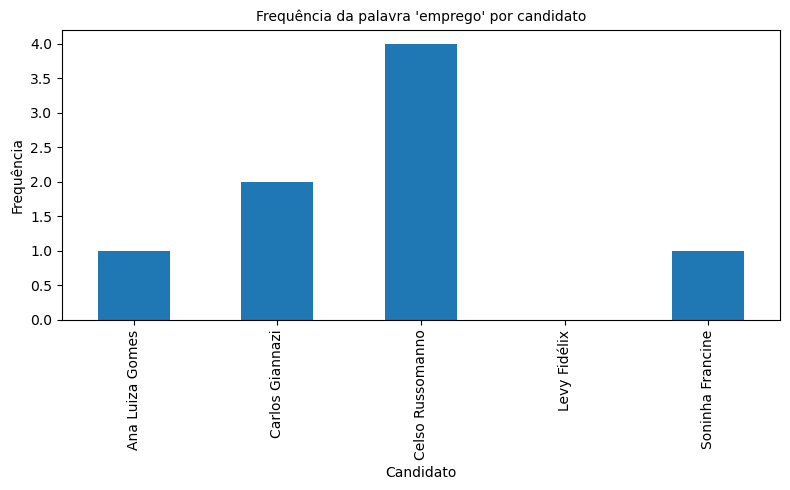

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Mapeamento e listagem de arquivos e nome do candidato para legenda do gráfico
arquivos = {
    "resultados/output_ana.txt": "Ana Luiza Gomes",
    "resultados/output_giannazi.txt": "Carlos Giannazi",
    "resultados/output_levy.txt": "Levy Fidélix",
    "resultados/output_russomanno.txt": "Celso Russomanno",
    "resultados/output_soninha.txt": "Soninha Francine"
}

dfs = []

# Leitura dos dados
for arquivo, nome in arquivos.items():
    df = pd.read_csv(arquivo, sep="\s+", engine="python", header=None)
    df.columns = ["Palavra", "Frequência"]

    df["Candidato"] = nome
    dfs.append(df)

# Concatenar todos os dados
df_total = pd.concat(dfs, ignore_index=True)

# Pivot
pivot = df_total.pivot_table(
    index="Palavra",
    columns="Candidato",
    values="Frequência",
    fill_value=0
)

# Palavras de interesse
palavras_interesse = ["transporte", "educação", "saúde", "segurança", "emprego"]

# Gráficos
for palavra in palavras_interesse:
    if palavra in pivot.index:
        dados = pivot.loc[palavra]
        print(dados)

        plt.figure(figsize=(8,5))
        dados.plot(kind="bar")

        plt.title(f"Frequência da palavra '{palavra}' por candidato", fontsize=10)
        plt.xlabel("Candidato")
        plt.ylabel("Frequência")

        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print(f"A palavra '{palavra}' não foi encontrada nos dados.")